# 3. 模型样本外预测比较

本 notebook 按 Research_Design_Roadmap.md 比较五个模型：

1. Rolling Normal
2. Linear Quantile
3. Fused Normal K1
4. Fused Normal K3
5. Structured Normal K3

比较规则固定为：只保留五个模型共同拥有的股票—月份；先计算股票层评分，再在每个月内等权平均，最后让月份等权。模型优劣只依据样本外预测评分，不使用资产组合收益。

主要指标：

- 5% FZ0 joint VaR--ES score，越低越好；
- 0%--10% tail-CRPS，越低越好。

次要指标包括 NLL、CRPS、1%/5%/10% Quantile Score、VaR coverage 和 PIT。Linear Quantile 没有天然密度，因此不计算精确 NLL；其 PIT 是由预测分位数插值得到的近似值。


In [76]:
# ==========================================
# 1. 导入库并设置路径、模型和评分参数
# ==========================================
from pathlib import Path
from datetime import datetime
import gc
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import trapezoid
from scipy.special import logsumexp
from scipy.stats import norm

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)


# 选择要使用的预测时间戳(不使用的版本就注释掉)
# timestamp = "20260829_0422" # normal
# timestamp = "20260827_2251" # rank
# # timestamp = "20260827_0616" # none
# timestamp = "20260831_0534" # rank+training 120 months
timestamp = "20260831_1640" # rank + training 72 months + ffi12
# timestamp = "20260831_1753" # normal + training 72 months + ffi12

project_root = Path("/Users/jianbinchen/NonSync/GitHub/Research/PricingTailRisk_MDN")
forecast_dir = Path("/Users/jianbinchen/Downloads/results")

result_dir = project_root / "output/model_comparison"
figure_dir = project_root / "overleaf/fig"

model_order = [
    "rolling_normal", 
    "linear_quantile", 
    "fused_normal_k1",
    "fused_normal_k3", 
    "structured_normal_k3",
]

model_labels = {
    "rolling_normal": "Rolling Normal",
    "linear_quantile": "Linear Quantile",
    "fused_normal_k1": "Fused Normal K1",
    "fused_normal_k3": "Fused Normal K3",
    "structured_normal_k3": "Structured Normal K3",
}

model_files = {
    "rolling_normal": forecast_dir / f"rolling_normal_forecasts_{timestamp}.parquet",
    "linear_quantile": forecast_dir / f"linear_quantile_forecasts_{timestamp}.parquet",
    "fused_normal_k1": forecast_dir / f"fused_k1_forecasts_{timestamp}.parquet",
    "fused_normal_k3": forecast_dir / f"fused_k3_forecasts_{timestamp}.parquet",
    "structured_normal_k3": forecast_dir / f"structured_forecasts_{timestamp}.parquet",
}

# ==========================================
# read all files and display the first few rows
# ==========================================
for model, file in model_files.items():
    df = pd.read_parquet(file)
    print(f"Model: {model}")
    display(pd.concat([df.head(3), df.tail(3)]))



Model: rolling_normal


,permno,mthcaldt,target_ret_final,model_id,pred_mean,pred_vol,history_n,var_1,es_1,var_5,es_5,var_10,es_10
0,10001,2007-01-31,0.264774,rolling_normal,0.012281,0.111545,84,-0.247211,0.285010,-0.171194,0.217804,-0.130669,0.183478
1,10025,2007-01-31,-0.028094,rolling_normal,0.019477,0.167332,84,-0.369795,0.426498,-0.255759,0.325681,-0.194967,0.274188
2,10026,2007-01-31,-0.038517,rolling_normal,0.022379,0.096136,84,-0.201266,0.233844,-0.135751,0.175922,-0.100824,0.146338
480443,93426,2024-12-31,-0.007243,rolling_normal,0.004015,0.098320,84,-0.224712,0.258029,-0.157707,0.198791,-0.121987,0.168535
480444,93434,2024-12-31,0.147685,rolling_normal,1.099275,1.366048,2,-2.078629,2.541536,-1.147674,1.718490,-0.651386,1.298117
480445,93436,2024-12-31,0.001882,rolling_normal,0.054494,0.204559,84,-0.421382,0.490701,-0.281976,0.367453,-0.207660,0.304504


Model: linear_quantile


,permno,mthcaldt,target_ret_final,model_id,validation_loss,epochs_run,pred_mean,pred_vol,var_1,es_1,var_5,es_5,var_10,es_10,quantile_levels,quantile_vec
0,10001,2007-01-31,0.264774,linear_quantile,0.012736,58,-0.008186,0.169305,-0.357132,0.412401,-0.237462,0.308624,-0.180557,0.258817,"[0.001, 0.0025, 0.005, 0.01, 0.025, 0.05, 0.1,...","[-0.48079025745391846, -0.4366788864135742, -0..."
1,10025,2007-01-31,-0.028094,linear_quantile,0.012736,58,-0.011804,0.208198,-0.466833,0.524098,-0.319225,0.408288,-0.241762,0.344391,"[0.001, 0.0025, 0.005, 0.01, 0.025, 0.05, 0.1,...","[-0.5683276653289795, -0.5430819988250732, -0...."
2,10026,2007-01-31,-0.038517,linear_quantile,0.012736,58,-0.012474,0.133748,-0.291396,0.341347,-0.195490,0.253971,-0.152133,0.213891,"[0.001, 0.0025, 0.005, 0.01, 0.025, 0.05, 0.1,...","[-0.3869573175907135, -0.3608119487762451, -0...."
480443,93426,2024-12-31,-0.007243,linear_quantile,0.016149,79,-0.017209,0.149149,-0.417049,0.488323,-0.256907,0.357380,-0.184107,0.288943,"[0.001, 0.0025, 0.005, 0.01, 0.025, 0.05, 0.1,...","[-0.5989918112754822, -0.523905873298645, -0.4..."
480444,93434,2024-12-31,0.147685,linear_quantile,0.016149,79,-0.023628,0.245051,-0.603238,0.702256,-0.390032,0.522804,-0.291380,0.431755,"[0.001, 0.0025, 0.005, 0.01, 0.025, 0.05, 0.1,...","[-0.8570428490638733, -0.7409366369247437, -0...."
480445,93436,2024-12-31,0.001882,linear_quantile,0.016149,79,-0.023367,0.157622,-0.395058,0.458589,-0.271260,0.349871,-0.213793,0.296199,"[0.001, 0.0025, 0.005, 0.01, 0.025, 0.05, 0.1,...","[-0.5467606782913208, -0.4824865460395813, -0...."


Model: fused_normal_k1


,permno,mthcaldt,target_ret_final,window,model_id,pi_vec,pi_logits_vec,mu_vec,sigma_vec,nu_vec,var_1,es_1,var_5,es_5,var_10,es_10
0,10001,2007-01-31,0.264774,0,fused_normal_k1,[1.0],[0.0],[0.013480894267559052],[0.11423509567975998],None,-0.252270,0.290980,-0.174419,0.222153,-0.132917,0.187000
1,10025,2007-01-31,-0.028094,0,fused_normal_k1,[1.0],[0.0],[-0.0070756529457867146],[0.13849738240242004],None,-0.329269,0.376201,-0.234884,0.292756,-0.184567,0.250136
2,10026,2007-01-31,-0.038517,0,fused_normal_k1,[1.0],[0.0],[-0.003198858816176653],[0.09585005789995193],None,-0.226179,0.258660,-0.160858,0.200910,-0.126036,0.171414
480443,93426,2024-12-31,-0.007243,17,fused_normal_k1,[1.0],[0.0],[0.01433954294770956],[0.12232233583927155],None,-0.270225,0.311676,-0.186863,0.237976,-0.142423,0.200334
480444,93434,2024-12-31,0.147685,17,fused_normal_k1,[1.0],[0.0],[0.003010000102221966],[0.29875263571739197],None,-0.691993,0.793230,-0.488394,0.613231,-0.379857,0.521296
480445,93436,2024-12-31,0.001882,17,fused_normal_k1,[1.0],[0.0],[-0.02080928161740303],[0.15022359788417816],None,-0.370282,0.421187,-0.267905,0.330677,-0.213329,0.284449


Model: fused_normal_k3


,permno,mthcaldt,target_ret_final,window,model_id,pi_vec,pi_logits_vec,mu_vec,sigma_vec,nu_vec,var_1,es_1,var_5,es_5,var_10,es_10
0,10001,2007-01-31,0.264774,0,fused_normal_k3,"[0.27000343799591064, 0.522145688533783, 0.207...","[-0.12497229874134064, 0.5345395803451538, -0....","[-0.013287877663969994, 0.011403180658817291, ...","[0.08551321923732758, 0.07616066932678223, 0.2...",None,-0.315473,0.406979,-0.163910,0.253428,-0.117128,0.195430
1,10025,2007-01-31,-0.028094,0,fused_normal_k3,"[0.3765127658843994, 0.4287175238132477, 0.194...","[0.18730294704437256, 0.31714925169944763, -0....","[-0.06455773115158081, 0.007287534885108471, 0...","[0.10382706671953201, 0.09341229498386383, 0.3...",None,-0.452872,0.584178,-0.243524,0.366395,-0.182553,0.287730
2,10026,2007-01-31,-0.038517,0,fused_normal_k3,"[0.2399177849292755, 0.5415216684341431, 0.218...","[-0.23771613836288452, 0.5763707160949707, -0....","[-0.006034683436155319, 0.0010895095765590668,...","[0.07406836748123169, 0.06495867669582367, 0.1...",None,-0.250505,0.316041,-0.140873,0.206408,-0.103022,0.162993
480443,93426,2024-12-31,-0.007243,17,fused_normal_k3,"[0.01244056224822998, 0.3441367745399475, 0.64...","[-2.3884174823760986, 0.931659460067749, 1.557...","[0.11964355409145355, 0.0046445876359939575, -...","[0.3511994183063507, 0.1341320425271988, 0.072...",None,-0.261777,0.333597,-0.164173,0.226487,-0.124318,0.184233
480444,93434,2024-12-31,0.147685,17,fused_normal_k3,"[0.02369285561144352, 0.5727038979530334, 0.40...","[-1.8648338317871094, 1.3203613758087158, 0.97...","[0.28800928592681885, -0.040308862924575806, -...","[0.7333284616470337, 0.22083774209022522, 0.11...",None,-0.538215,0.704140,-0.355562,0.480284,-0.272425,0.394843
480445,93436,2024-12-31,0.001882,17,fused_normal_k3,"[0.02096131443977356, 0.46318966150283813, 0.5...","[-2.0416789054870605, 1.0537790060043335, 1.16...","[0.12103810906410217, -0.03292977064847946, -0...","[0.359854519367218, 0.14445491135120392, 0.087...",None,-0.339938,0.416326,-0.230052,0.300297,-0.180451,0.251451


Model: structured_normal_k3


,permno,mthcaldt,target_ret_final,window,adverse_component,normal_component,favorable_component,model_id,pi_vec,pi_logits_vec,mu_vec,sigma_vec,nu_vec,var_1,es_1,var_5,es_5,var_10,es_10
0,10001,2007-01-31,0.264774,0,1,2,0,structured_normal_k3,"[0.113340824842453, 0.5285136699676514, 0.3581...","[-0.9614662528038025, 0.5782029628753662, 0.18...","[0.1298636496067047, 0.002417616546154022, -0....","[0.18544413149356842, 0.08298581838607788, 0.0...",None,-0.192565,0.242034,-0.126501,0.169206,-0.096327,0.139562
1,10025,2007-01-31,-0.028094,0,1,2,0,structured_normal_k3,"[0.113340824842453, 0.5285136699676514, 0.3581...","[-0.9614662528038025, 0.5782029628753662, 0.18...","[0.15086984634399414, -0.0834188163280487, 0.0...","[0.20183180272579193, 0.13692262768745422, 0.1...",None,-0.371589,0.421633,-0.269773,0.332184,-0.214963,0.286083
2,10026,2007-01-31,-0.038517,0,1,2,0,structured_normal_k3,"[0.113340824842453, 0.5285136699676514, 0.3581...","[-0.9614662528038025, 0.5782029628753662, 0.18...","[0.09510147571563721, -0.034472014755010605, 0...","[0.11469686776399612, 0.07487363368272781, 0.0...",None,-0.192336,0.219982,-0.136563,0.170743,-0.107137,0.145628
480443,93426,2024-12-31,-0.007243,17,0,1,2,structured_normal_k3,"[0.254055380821228, 0.6860688924789429, 0.0598...","[0.08684087544679642, 1.0802665948867798, -1.3...","[-0.09150286018848419, 0.03706655651330948, 0....","[0.07828476279973984, 0.07130841165781021, 0.2...",None,-0.243529,0.295039,-0.167370,0.216650,-0.126004,0.180820
480444,93434,2024-12-31,0.147685,17,0,1,2,structured_normal_k3,"[0.254055380821228, 0.6860688924789429, 0.0598...","[0.08684087544679642, 1.0802665948867798, -1.3...","[-0.18249942362308502, 0.020507389679551125, 0...","[0.1596684455871582, 0.1779317855834961, 0.458...",None,-0.513539,0.632461,-0.365104,0.463546,-0.291298,0.394223
480445,93436,2024-12-31,0.001882,17,0,1,2,structured_normal_k3,"[0.254055380821228, 0.6860688924789429, 0.0598...","[0.08684087544679642, 1.0802665948867798, -1.3...","[-0.11416181176900864, 0.044104091823101044, 0...","[0.08528715372085571, 0.08420176804065704, 0.2...",None,-0.284736,0.354058,-0.198129,0.255970,-0.151934,0.214576


In [77]:
alphas = (0.01, 0.05, 0.10)
alpha_suffix = {0.01: "1", 0.05: "5", 0.10: "10"}
quantile_levels = np.array([
    0.001, 0.0025, 0.005, 0.01, 0.025, 0.05, 0.10, 0.25, 0.50,
    0.75, 0.90, 0.95, 0.975, 0.99, 0.995, 0.9975, 0.999,
])
tail_alpha = 0.1
score_chunk_size = 20_000
bisection_iterations = 40
newey_west_lags = 12
save_row_scores = False  # True 会额外保存五个较大的股票层评分文件

In [78]:
# ==========================================
# 2. 建立五个模型的共同股票—月份样本
# ==========================================
# 主要为了生成commen_index
key_cols = ["permno", "mthcaldt"]
tail_cols = [f"{name}_{alpha_suffix[alpha]}" for alpha in alphas for name in ("var", "es")]

coverage_rows, target_series = [], {}
common_index = None

for model_id in model_order:
    path = model_files[model_id]
    core = pd.read_parquet(path, columns=key_cols + ["target_ret_final"])
    core["mthcaldt"] = pd.to_datetime(core["mthcaldt"])
    if core.duplicated(key_cols).any():
        raise ValueError(f"{model_id} 存在重复股票—月份。")

    indexed_target = core.set_index(key_cols)["target_ret_final"].sort_index()
    target_series[model_id] = indexed_target
    common_index = indexed_target.index if common_index is None else common_index.intersection(indexed_target.index, sort=False)
    coverage_rows.append({
        "model_id": model_id, "available_rows": len(core), "months": core["mthcaldt"].nunique(),
        "first_month": core["mthcaldt"].min(), "last_month": core["mthcaldt"].max(),
    })

common_index = common_index.sort_values()
if len(common_index) == 0:
    raise ValueError("五个模型没有共同股票—月份。")

reference_target = target_series[model_order[0]].reindex(common_index).to_numpy()
for model_id in model_order[1:]:
    difference = np.nanmax(np.abs(target_series[model_id].reindex(common_index).to_numpy() - reference_target))
    if difference > 1e-10:
        raise ValueError(f"{model_id} 与 Rolling Normal 的 realized return 不一致，最大差异为 {difference:g}。")

coverage_table = pd.DataFrame(coverage_rows).set_index("model_id").reindex(model_order)
coverage_table["common_rows"] = len(common_index)
coverage_table["common_share"] = coverage_table["common_rows"] / coverage_table["available_rows"]
del target_series, core
gc.collect()

print(f"共同样本：{len(common_index):,} 个股票—月份，共 {common_index.get_level_values('mthcaldt').nunique()} 个月")
display(coverage_table)
# display(coverage_table.reset_index())

coverage_table = coverage_table.reset_index()
coverage_table.to_parquet(result_dir / f"coverage_table_{timestamp}.parquet", index=False)


共同样本：480,446 个股票—月份，共 216 个月


,available_rows,months,first_month,last_month,common_rows,common_share
model_id,,,,,,
rolling_normal,480446,216,2007-01-31,2024-12-31,480446,1.0
linear_quantile,480446,216,2007-01-31,2024-12-31,480446,1.0
fused_normal_k1,480446,216,2007-01-31,2024-12-31,480446,1.0
fused_normal_k3,480446,216,2007-01-31,2024-12-31,480446,1.0
structured_normal_k3,480446,216,2007-01-31,2024-12-31,480446,1.0


In [79]:
# ==========================================
# 3. 确定 FZ0 的共同有效样本
# ==========================================
# FZ0 要求 q < 0、e < 0 且 e <= q，其中 e = -loss_ES。
fz_common_masks = {alpha: np.ones(len(common_index), dtype=bool) for alpha in alphas}
fz_domain_rows = []

for model_id in model_order:
    tail_path = model_files[model_id]
    tail = pd.read_parquet(tail_path, columns=key_cols + tail_cols)
    tail["mthcaldt"] = pd.to_datetime(tail["mthcaldt"])
    tail = tail.set_index(key_cols).reindex(common_index)

    for alpha in alphas:
        suffix = alpha_suffix[alpha]
        q = tail[f"var_{suffix}"].to_numpy(dtype=float)
        e = -tail[f"es_{suffix}"].to_numpy(dtype=float)
        valid = np.isfinite(q) & np.isfinite(e) & (q < 0.0) & (e < 0.0) & (e <= q)
        fz_common_masks[alpha] &= valid
        fz_domain_rows.append({"model_id": model_id, "alpha": alpha, "model_valid_share": valid.mean()})

fz_domain_table = pd.DataFrame(fz_domain_rows)
common_shares = {alpha: mask.mean() for alpha, mask in fz_common_masks.items()}
fz_domain_table["all_model_common_share"] = fz_domain_table["alpha"].map(common_shares)
del tail
gc.collect()

display(fz_domain_table.pivot(index="model_id", columns="alpha", values="model_valid_share").reindex(model_order).round(6))
print("FZ0 五模型共同有效样本比例：", {f"{alpha:.0%}": f"{share:.2%}" for alpha, share in common_shares.items()})
fz_domain_table.to_parquet(result_dir / f"fz_domain_table_{timestamp}.parquet", index=False)


alpha,0.01,0.05,0.10
model_id,,,
rolling_normal,0.998262,0.997396,0.996330
linear_quantile,0.996955,0.988244,0.974380
fused_normal_k1,1.000000,0.999998,0.998655
fused_normal_k3,1.000000,0.999286,0.991785
structured_normal_k3,1.000000,1.000000,1.000000


FZ0 五模型共同有效样本比例： {'1%': '99.52%', '5%': '98.49%', '10%': '96.28%'}


In [80]:
fz_domain_table

,model_id,alpha,model_valid_share,all_model_common_share
0,rolling_normal,0.01,0.998262,0.995219
1,rolling_normal,0.05,0.997396,0.984949
2,rolling_normal,0.10,0.996330,0.962768
3,linear_quantile,0.01,0.996955,0.995219
4,linear_quantile,0.05,0.988244,0.984949
5,linear_quantile,0.10,0.974380,0.962768
6,fused_normal_k1,0.01,1.000000,0.995219
7,fused_normal_k1,0.05,0.999998,0.984949
8,fused_normal_k1,0.10,0.998655,0.962768
9,fused_normal_k3,0.01,1.000000,0.995219


## 评分方法

CRPS 与 tail-CRPS 都用五个模型共享的 17 个分位数网格进行梯形积分。网格两端使用最外侧分位数作常数延伸，因此所有模型采用完全相同的离散近似。

FZ0 使用 return-space ES：

$$
e_{i,t,\alpha}=-ES^{loss}_{i,t,\alpha}.
$$

评分公式为：

$$
L_{FZ0}(y,q,e;\alpha)
=
-\frac{\mathbf 1(y\le q)(q-y)}{\alpha e}
+\frac{q}{e}+\log(-e)-1.
$$

为了不让不同模型使用不同观测，FZ0 仅在五个模型共同满足定义域的股票—月份上计算。保留比例由上表报告。


In [81]:
# ==========================================
# 4. 通用评分函数
# ==========================================
def decode_matrix(series):
    """将 parquet 中的 JSON/list 向量列转成二维 NumPy array。"""
    return np.stack([json.loads(x) if isinstance(x, str) else x for x in series]).astype(float, copy=False)


def pinball_loss(y, levels, quantiles):
    error = y[:, None] - quantiles
    return np.where(error >= 0.0, levels[None, :] * error, (levels[None, :] - 1.0) * error)


def score_quantile_grid(y, quantiles):
    """用共同分位数网格计算 CRPS、10% tail-CRPS 和 1%/5%/10% Quantile Score。"""
    quantiles = np.sort(np.asarray(quantiles, dtype=float), axis=1)
    full_levels = np.r_[0.0, quantile_levels, 1.0]
    full_quantiles = np.column_stack([quantiles[:, 0], quantiles, quantiles[:, -1]])
    crps = 2.0 * trapezoid(pinball_loss(y, full_levels, full_quantiles), full_levels, axis=1)

    tail_mask = quantile_levels <= tail_alpha
    tail_levels = np.r_[0.0, quantile_levels[tail_mask]]
    tail_quantiles = np.column_stack([quantiles[:, 0], quantiles[:, tail_mask]])
    tail_crps = 2.0 * trapezoid(pinball_loss(y, tail_levels, tail_quantiles), tail_levels, axis=1) / tail_alpha

    scores = {"crps": crps, "tail_crps_10": tail_crps}
    for alpha in alphas:
        position = np.flatnonzero(np.isclose(quantile_levels, alpha))[0]
        scores[f"qs_{alpha_suffix[alpha]}"] = 2.0 * pinball_loss(y, np.array([alpha]), quantiles[:, [position]])[:, 0]
    return scores


def pit_from_quantiles(y, quantiles):
    """由单调分位数函数反推 Linear Quantile 的近似 PIT。"""
    quantiles = np.sort(np.asarray(quantiles, dtype=float), axis=1)
    count = (quantiles <= y[:, None]).sum(axis=1)
    pit = np.empty(len(y), dtype=float)
    below, above = count == 0, count == len(quantile_levels)
    pit[below], pit[above] = 0.0, 1.0

    middle_rows = np.flatnonzero(~(below | above))
    left = count[middle_rows] - 1
    right = left + 1
    q_left, q_right = quantiles[middle_rows, left], quantiles[middle_rows, right]
    fraction = np.divide(
        y[middle_rows] - q_left, q_right - q_left,
        out=np.full(len(middle_rows), 0.5), where=(q_right - q_left) > 1e-12,
    )
    pit[middle_rows] = quantile_levels[left] + fraction * (quantile_levels[right] - quantile_levels[left])
    return np.clip(pit, 0.0, 1.0)


def mixture_cdf(x, pi, mu, sigma):
    z = (x[..., None] - mu[:, None, :]) / sigma[:, None, :]
    return np.sum(pi[:, None, :] * norm.cdf(z), axis=2)


def mixture_quantiles(levels, pi, mu, sigma):
    """向量化二分法计算 Normal mixture quantiles。"""
    bracket_level = max(float(np.min(levels)) * 0.1, 1e-10)
    lower_component = mu + sigma * norm.ppf(bracket_level)
    upper_component = mu + sigma * norm.ppf(1.0 - bracket_level)
    lower = np.repeat(lower_component.min(axis=1)[:, None], len(levels), axis=1)
    upper = np.repeat(upper_component.max(axis=1)[:, None], len(levels), axis=1)

    for _ in range(bisection_iterations):
        middle = 0.5 * (lower + upper)
        cdf = mixture_cdf(middle, pi, mu, sigma)
        lower = np.where(cdf < levels[None, :], middle, lower)
        upper = np.where(cdf >= levels[None, :], middle, upper)
    return 0.5 * (lower + upper)


def fz0_score(y, q, es_loss, alpha, common_valid):
    e = -np.asarray(es_loss, dtype=float)
    score = np.full(len(y), np.nan)
    hit = (y <= q).astype(float)
    score[common_valid] = (
        -hit[common_valid] * (q[common_valid] - y[common_valid]) / (alpha * e[common_valid])
        + q[common_valid] / e[common_valid] + np.log(-e[common_valid]) - 1.0
    )
    return score


def uniform_ks_distance(values):
    values = np.sort(np.asarray(values, dtype=float))
    n = len(values)
    return max((np.arange(1, n + 1) / n - values).max(), (values - np.arange(n) / n).max())


In [82]:
# ==========================================
# 5. 读取单个模型，并计算股票层评分
# ==========================================
def load_model(model_id):
    files = model_files[model_id]
    if model_id == "rolling_normal":
        columns = key_cols + ["target_ret_final", "model_id", "pred_mean", "pred_vol"] + tail_cols
    elif model_id == "linear_quantile":
        columns = key_cols + ["target_ret_final", "model_id", "quantile_levels", "quantile_vec"] + tail_cols
    else:
        columns = key_cols + ["target_ret_final", "model_id", "pi_vec", "mu_vec", "sigma_vec"] + tail_cols

    frame = pd.read_parquet(files, columns=columns)
    frame["mthcaldt"] = pd.to_datetime(frame["mthcaldt"])

    return frame.reset_index()


def score_model(model_id):
    frame = load_model(model_id)
    y = frame["target_ret_final"].to_numpy(dtype=float)
    n = len(frame)
    nll = np.full(n, np.nan)
    pit = np.full(n, np.nan)

    if model_id == "rolling_normal":
        loc = frame["pred_mean"].to_numpy(dtype=float)
        scale = np.maximum(frame["pred_vol"].to_numpy(dtype=float), 1e-8)
        quantiles = loc[:, None] + scale[:, None] * norm.ppf(quantile_levels)[None, :]
        nll = -norm.logpdf(y, loc=loc, scale=scale)
        pit = norm.cdf(y, loc=loc, scale=scale)

    elif model_id == "linear_quantile":
        stored_levels = frame["quantile_levels"].iloc[0]
        stored_levels = np.asarray(json.loads(stored_levels) if isinstance(stored_levels, str) else stored_levels, dtype=float)
        if not np.allclose(stored_levels, quantile_levels):
            raise ValueError("Linear Quantile 的 quantile_levels 与比较网格不一致。")
        quantiles = np.sort(decode_matrix(frame["quantile_vec"]), axis=1)
        pit = pit_from_quantiles(y, quantiles)

    else:
        pi = decode_matrix(frame["pi_vec"])
        mu = decode_matrix(frame["mu_vec"])
        sigma = decode_matrix(frame["sigma_vec"])
        if np.any(sigma <= 0.0) or not np.allclose(pi.sum(axis=1), 1.0, atol=1e-5):
            raise ValueError(f"{model_id} 的 pi 或 sigma 无效。")

        quantiles = np.empty((n, len(quantile_levels)), dtype=float)
        for start in range(0, n, score_chunk_size):
            stop = min(start + score_chunk_size, n)
            sl = slice(start, stop)
            log_density = np.log(np.clip(pi[sl], 1e-12, 1.0)) + norm.logpdf(y[sl, None], loc=mu[sl], scale=sigma[sl])
            nll[sl] = -logsumexp(log_density, axis=1)
            pit[sl] = np.sum(pi[sl] * norm.cdf(y[sl, None], loc=mu[sl], scale=sigma[sl]), axis=1)
            quantiles[sl] = mixture_quantiles(quantile_levels, pi[sl], mu[sl], sigma[sl])

    # 1%、5%、10% 分位数使用预测文件中已经保存的 VaR，并检查与本次分位数计算一致。
    quantile_differences = {}
    for alpha in alphas:
        suffix = alpha_suffix[alpha]
        position = np.flatnonzero(np.isclose(quantile_levels, alpha))[0]
        stored_var = frame[f"var_{suffix}"].to_numpy(dtype=float)
        quantile_differences[f"var_{suffix}_max_abs_diff"] = np.max(np.abs(quantiles[:, position] - stored_var))
        quantiles[:, position] = stored_var

    grid_scores = score_quantile_grid(y, quantiles)
    output = frame[key_cols].copy()
    output["target_ret_final"] = y
    output["model_id"] = model_id
    output["nll"] = nll
    output["pit"] = np.clip(pit, 0.0, 1.0)
    for name, values in grid_scores.items():
        output[name] = values

    for alpha in alphas:
        suffix = alpha_suffix[alpha]
        q = frame[f"var_{suffix}"].to_numpy(dtype=float)
        es_loss = frame[f"es_{suffix}"].to_numpy(dtype=float)
        output[f"coverage_{suffix}"] = (y <= q).astype(float)
        output[f"fz0_{suffix}"] = fz0_score(y, q, es_loss, alpha, fz_common_masks[alpha])

    return output, {"model_id": model_id, **quantile_differences}


In [83]:
# ==========================================
# 6. 逐个模型评分，并立即聚合到月度层
# ==========================================
loss_columns = ["nll", "crps", "tail_crps_10", "qs_1", "qs_5", "qs_10", "fz0_1", "fz0_5", "fz0_10"]
coverage_columns = ["coverage_1", "coverage_5", "coverage_10"]
monthly_parts, pit_parts, pit_hist_parts, quantile_checks = [], [], [], []

for model_id in model_order:
    print(f"Scoring {model_labels[model_id]} ...")
    row_scores, check = score_model(model_id)
    quantile_checks.append(check)

    monthly = row_scores.groupby("mthcaldt", as_index=False).agg(
        n_firms=("permno", "size"),
        **{column: (column, "mean") for column in loss_columns + coverage_columns},
        **{f"n_{column}": (column, "count") for column in ["fz0_1", "fz0_5", "fz0_10"]},
    )
    monthly["model_id"] = model_id
    monthly_parts.append(monthly)

    for month, group in row_scores.groupby("mthcaldt", sort=True):
        values = group["pit"].to_numpy(dtype=float)
        pit_parts.append({
            "model_id": model_id, "mthcaldt": month, "pit_mean": values.mean(),
            "pit_variance": values.var(ddof=0), "pit_ks": uniform_ks_distance(values),
        })

    pit_bin = np.minimum((row_scores["pit"].to_numpy() * 10).astype(int), 9)
    month_bins = pd.crosstab(row_scores["mthcaldt"], pit_bin).reindex(columns=range(10), fill_value=0)
    month_bins = month_bins.div(month_bins.sum(axis=1), axis=0)
    pit_hist_parts.append(pd.DataFrame({
        "model_id": model_id, "pit_bin": np.arange(10), "frequency": month_bins.mean(axis=0).to_numpy(),
    }))

    if save_row_scores:
        row_scores.to_parquet(result_dir / f"row_scores_{model_id}_{timestamp}.parquet", index=False)

    del row_scores, monthly, month_bins
    gc.collect()

monthly_scores = pd.concat(monthly_parts, ignore_index=True)
monthly_pit = pd.DataFrame(pit_parts)
pit_histogram = pd.concat(pit_hist_parts, ignore_index=True)
quantile_check_table = pd.DataFrame(quantile_checks).set_index("model_id").reindex(model_order)

print("全部模型评分完成。")
display(monthly_scores)
display(monthly_pit)
display(pit_histogram)
display(quantile_check_table)
monthly_scores.to_parquet(result_dir / f"monthly_scores_{timestamp}.parquet", index=False)
monthly_pit.to_parquet(result_dir / f"monthly_pit_{timestamp}.parquet", index=False)
pit_histogram.to_parquet(result_dir / f"pit_histogram_{timestamp}.parquet", index=False)
quantile_check_table.reset_index().to_parquet(result_dir / f"quantile_check_table_{timestamp}.parquet", index=False)

Scoring Rolling Normal ...
Scoring Linear Quantile ...
Scoring Fused Normal K1 ...
Scoring Fused Normal K3 ...
Scoring Structured Normal K3 ...
全部模型评分完成。


,mthcaldt,n_firms,nll,crps,tail_crps_10,qs_1,qs_5,qs_10,fz0_1,fz0_5,fz0_10,coverage_1,coverage_5,coverage_10,n_fz0_1,n_fz0_5,n_fz0_10,model_id
0,2007-01-31,2870,7.968089,0.057608,0.023440,0.008180,0.025175,0.039064,-0.878187,-1.358727,-1.632966,0.007666,0.026481,0.051568,2846,2787,2697,rolling_normal
1,2007-02-28,2871,-0.755286,0.055446,0.023788,0.007866,0.025542,0.040246,-0.884470,-1.319830,-1.703426,0.007315,0.025427,0.046674,2858,2839,2778,rolling_normal
2,2007-03-31,2854,-0.739022,0.055707,0.024140,0.007801,0.025918,0.041095,-1.027994,-1.481971,-1.829301,0.004205,0.016468,0.029783,2835,2802,2731,rolling_normal
3,2007-04-30,2864,0.790061,0.062103,0.024616,0.007597,0.026389,0.042381,-0.991123,-1.442699,-1.400059,0.006285,0.017458,0.033869,2853,2823,2764,rolling_normal
4,2007-05-31,2863,-0.653724,0.056303,0.022257,0.007629,0.024038,0.036995,0.245376,-1.172941,-1.089091,0.011876,0.038421,0.065316,2843,2800,2705,rolling_normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1075,2024-08-31,2059,-0.800401,0.064514,0.024936,0.007459,0.026422,0.043845,-1.142822,-1.473710,-1.667374,0.006314,0.013113,0.028655,2046,2041,2004,structured_normal_k3
1076,2024-09-30,2052,-0.768035,0.066387,0.023927,0.007290,0.025355,0.041880,-1.038160,-1.389416,-1.575284,0.012671,0.035088,0.066764,2044,2023,1989,structured_normal_k3
1077,2024-10-31,2076,-0.198448,0.103763,0.032898,0.009843,0.034563,0.058524,-1.008217,-1.456010,-1.682664,0.008671,0.027457,0.041908,2063,2046,1992,structured_normal_k3
1078,2024-11-30,2088,-0.693939,0.070527,0.023481,0.007742,0.024824,0.040575,-0.884715,-1.212390,-1.343618,0.022031,0.079502,0.160441,2071,2050,2017,structured_normal_k3


,model_id,mthcaldt,pit_mean,pit_variance,pit_ks
0,rolling_normal,2007-01-31,0.445982,0.049110,0.176221
1,rolling_normal,2007-02-28,0.475499,0.048912,0.143390
2,rolling_normal,2007-03-31,0.521640,0.050903,0.137839
3,rolling_normal,2007-04-30,0.536022,0.059872,0.120154
4,rolling_normal,2007-05-31,0.418107,0.050020,0.201955
...,...,...,...,...,...
1075,structured_normal_k3,2024-08-31,0.602334,0.053063,0.212313
1076,structured_normal_k3,2024-09-30,0.506133,0.069869,0.056352
1077,structured_normal_k3,2024-10-31,0.696015,0.079284,0.293765
1078,structured_normal_k3,2024-11-30,0.367653,0.064895,0.226459


,model_id,pit_bin,frequency
0,rolling_normal,0,0.101303
1,rolling_normal,1,0.095329
2,rolling_normal,2,0.109044
3,rolling_normal,3,0.119413
4,rolling_normal,4,0.123025
5,rolling_normal,5,0.109880
6,rolling_normal,6,0.095668
7,rolling_normal,7,0.084248
8,rolling_normal,8,0.072396
9,rolling_normal,9,0.089694


,var_1_max_abs_diff,var_5_max_abs_diff,var_10_max_abs_diff
model_id,,,
rolling_normal,0.000000e+00,0.000000e+00,0.000000e+00
linear_quantile,0.000000e+00,0.000000e+00,0.000000e+00
fused_normal_k1,2.762235e-13,1.289968e-12,5.834222e-13
fused_normal_k3,3.177347e-12,3.168632e-12,3.157419e-12
structured_normal_k3,2.291944e-12,2.151279e-12,2.314482e-12


In [93]:
# ==========================================
# 7. 月份等权的模型比较结果
# ==========================================
summary_columns = loss_columns + coverage_columns
comparison_summary = monthly_scores.groupby("model_id")[summary_columns].mean().reindex(model_order)
comparison_summary.insert(0, "months", monthly_scores.groupby("model_id")["mthcaldt"].nunique().reindex(model_order))
comparison_summary.insert(1, "mean_firms_per_month", monthly_scores.groupby("model_id")["n_firms"].mean().reindex(model_order))

for alpha in alphas:
    suffix = alpha_suffix[alpha]
    comparison_summary[f"coverage_error_{suffix}"] = comparison_summary[f"coverage_{suffix}"] - alpha
    comparison_summary[f"fz0_months_{suffix}"] = monthly_scores.groupby("model_id")[f"fz0_{suffix}"].count().reindex(model_order)

comparison_summary["rank_fz0_5"] = comparison_summary["fz0_5"].rank(method="min")
comparison_summary["rank_tail_crps_10"] = comparison_summary["tail_crps_10"].rank(method="min")

primary_table = comparison_summary[["fz0_5", "fz0_months_5", "rank_fz0_5", "tail_crps_10", "rank_tail_crps_10"]]
# 次要预测评分：score 与对应 rank 紧邻，所有 score 都是越低越好。
secondary_score_metrics = ["nll", "crps", "qs_1", "qs_5", "qs_10", "fz0_1", "fz0_10"]
secondary_score_columns = []
for metric in secondary_score_metrics:
    rank_column = f"rank_{metric}"
    comparison_summary[rank_column] = comparison_summary[metric].rank(method="min", ascending=True)
    secondary_score_columns.extend([metric, rank_column])

secondary_score_table = comparison_summary[secondary_score_columns].copy()

# Coverage 的好坏取决于离目标 alpha 的绝对距离，而不是 coverage rate 本身的大小。
secondary_coverage_columns = []
coverage_rank_columns = []
for alpha in alphas:
    suffix = alpha_suffix[alpha]
    rank_column = f"rank_abs_coverage_error_{suffix}"
    comparison_summary[rank_column] = comparison_summary[f"coverage_error_{suffix}"].abs().rank(
        method="min", ascending=True
    )
    secondary_coverage_columns.extend([
        f"coverage_{suffix}", f"coverage_error_{suffix}", rank_column,
    ])
    coverage_rank_columns.append(rank_column)

secondary_coverage_table = comparison_summary[secondary_coverage_columns].copy()

# 保留一张完整的 secondary_table，方便后续保存或继续分析。
secondary_table = comparison_summary[secondary_score_columns + secondary_coverage_columns].copy()

def style_rank_table(table, rank_columns):
    """Rank 1 为深绿色；Linear Quantile 缺失的 NLL/rank 显示为破折号。"""
    return (
        table.rename(index=model_labels)
        .style
        .format(precision=6, na_rep="—")
        .format({column: "{:.0f}" for column in rank_columns}, na_rep="—")
        .background_gradient(
            subset=rank_columns, cmap="YlGn_r", vmin=1, vmax=len(model_order)
        )
        .set_properties(subset=rank_columns, **{"font-weight": "bold"})
    )

print("主要指标（score 越低、rank 越小越好）：")
# display(primary_table.rename(index=model_labels).round(6))
display(style_rank_table(primary_table, ["rank_fz0_5", "rank_tail_crps_10"]))



print("次要预测评分（score 越低、rank 越小越好）：")
display(style_rank_table(secondary_score_table, [f"rank_{metric}" for metric in secondary_score_metrics]))
print("VaR coverage 校准（|coverage error| 越小、rank 越小越好）：")
display(style_rank_table(secondary_coverage_table, coverage_rank_columns))
display(comparison_summary)
comparison_summary.reset_index().to_parquet(result_dir / f"comparison_summary_{timestamp}.parquet", index=False)


主要指标（score 越低、rank 越小越好）：


,fz0_5,fz0_months_5,rank_fz0_5,tail_crps_10,rank_tail_crps_10
model_id,,,,,
Rolling Normal,-1.123400,216,3,0.029370,3
Linear Quantile,-0.101718,216,5,0.029658,5
Fused Normal K1,-1.194602,216,2,0.028619,2
Fused Normal K3,-1.107867,216,4,0.029464,4
Structured Normal K3,-1.249098,216,1,0.027792,1


次要预测评分（score 越低、rank 越小越好）：


,nll,rank_nll,crps,rank_crps,qs_1,rank_qs_1,qs_5,rank_qs_5,qs_10,rank_qs_10,fz0_1,rank_fz0_1,fz0_10,rank_fz0_10
model_id,,,,,,,,,,,,,,
Rolling Normal,61486.848591,4,0.073582,2,0.010932,5,0.031244,3,0.048734,2,-0.016419,5,-1.281620,3
Linear Quantile,—,—,0.078339,5,0.009465,4,0.031586,5,0.051127,5,-0.409896,4,-0.600207,5
Fused Normal K1,-0.476535,3,0.076073,3,0.008981,2,0.030376,2,0.049702,3,-0.720875,3,-1.402141,2
Fused Normal K3,-0.531278,2,0.077778,4,0.009029,3,0.031490,4,0.050951,4,-0.775057,2,-1.280554,4
Structured Normal K3,-0.624305,1,0.072622,1,0.008743,1,0.029619,1,0.047983,1,-0.808196,1,-1.477641,1


VaR coverage 校准（|coverage error| 越小、rank 越小越好）：


,coverage_1,coverage_error_1,rank_abs_coverage_error_1,coverage_5,coverage_error_5,rank_abs_coverage_error_5,coverage_10,coverage_error_10,rank_abs_coverage_error_10
model_id,,,,,,,,,
Rolling Normal,0.022888,0.012888,5,0.058581,0.008581,3,0.101303,0.001303,2
Linear Quantile,0.015292,0.005292,1,0.057013,0.007013,2,0.099653,-0.000347,1
Fused Normal K1,0.019415,0.009415,4,0.051760,0.001760,1,0.086749,-0.013251,5
Fused Normal K3,0.017651,0.007651,2,0.066574,0.016574,5,0.110358,0.010358,4
Structured Normal K3,0.019286,0.009286,3,0.063621,0.013621,4,0.108717,0.008717,3


,months,mean_firms_per_month,nll,crps,tail_crps_10,qs_1,qs_5,qs_10,fz0_1,fz0_5,fz0_10,coverage_1,coverage_5,coverage_10,coverage_error_1,fz0_months_1,coverage_error_5,fz0_months_5,coverage_error_10,fz0_months_10,rank_fz0_5,rank_tail_crps_10,rank_nll,rank_crps,rank_qs_1,rank_qs_5,rank_qs_10,rank_fz0_1,rank_fz0_10,rank_abs_coverage_error_1,rank_abs_coverage_error_5,rank_abs_coverage_error_10
model_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
rolling_normal,216,2224.287037,61486.848591,0.073582,0.029370,0.010932,0.031244,0.048734,-0.016419,-1.123400,-1.281620,0.022888,0.058581,0.101303,0.012888,216,0.008581,216,0.001303,216,3.0,3.0,4.0,2.0,5.0,3.0,2.0,5.0,3.0,5.0,3.0,2.0
linear_quantile,216,2224.287037,NaN,0.078339,0.029658,0.009465,0.031586,0.051127,-0.409896,-0.101718,-0.600207,0.015292,0.057013,0.099653,0.005292,216,0.007013,216,-0.000347,216,5.0,5.0,NaN,5.0,4.0,5.0,5.0,4.0,5.0,1.0,2.0,1.0
fused_normal_k1,216,2224.287037,-0.476535,0.076073,0.028619,0.008981,0.030376,0.049702,-0.720875,-1.194602,-1.402141,0.019415,0.051760,0.086749,0.009415,216,0.001760,216,-0.013251,216,2.0,2.0,3.0,3.0,2.0,2.0,3.0,3.0,2.0,4.0,1.0,5.0
fused_normal_k3,216,2224.287037,-0.531278,0.077778,0.029464,0.009029,0.031490,0.050951,-0.775057,-1.107867,-1.280554,0.017651,0.066574,0.110358,0.007651,216,0.016574,216,0.010358,216,4.0,4.0,2.0,4.0,3.0,4.0,4.0,2.0,4.0,2.0,5.0,4.0
structured_normal_k3,216,2224.287037,-0.624305,0.072622,0.027792,0.008743,0.029619,0.047983,-0.808196,-1.249098,-1.477641,0.019286,0.063621,0.108717,0.009286,216,0.013621,216,0.008717,216,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,3.0,4.0,3.0


In [85]:
# ==========================================
# 8. 对预先指定的模型阶梯做 Newey-West 比较
# ==========================================
def newey_west_mean_test(values, lags=12):
    """检验月度 loss differential 的均值是否为 0。"""
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    n = len(values)
    if n < 3:
        return np.nan, np.nan, np.nan, np.nan, n

    centered = values - values.mean()
    max_lag = min(lags, n - 1)
    long_run_variance = np.dot(centered, centered) / n
    for lag in range(1, max_lag + 1):
        autocovariance = np.dot(centered[lag:], centered[:-lag]) / n
        long_run_variance += 2.0 * (1.0 - lag / (max_lag + 1.0)) * autocovariance

    standard_error = np.sqrt(max(long_run_variance, 0.0) / n)
    t_stat = values.mean() / standard_error if standard_error > 0 else np.nan
    p_value = 2.0 * norm.sf(abs(t_stat)) if np.isfinite(t_stat) else np.nan
    return values.mean(), standard_error, t_stat, p_value, n


model_steps = [
    ("linear_quantile", "rolling_normal", "条件信息"),
    ("fused_normal_k1", "linear_quantile", "非线性单分布"),
    ("fused_normal_k3", "fused_normal_k1", "Mixture"),
    ("structured_normal_k3", "fused_normal_k3", "结构化参数映射"),
]
# 这是预先指定的 stepwise 比较；前两步同时改变模型形式，不能解释为单一机制的因果识别。
test_metrics = ["fz0_5", "tail_crps_10", "crps", "qs_1", "qs_5", "qs_10", "nll"]
pairwise_rows = []

for candidate, benchmark, interpretation in model_steps:
    left = monthly_scores[monthly_scores["model_id"] == candidate][["mthcaldt"] + test_metrics]
    right = monthly_scores[monthly_scores["model_id"] == benchmark][["mthcaldt"] + test_metrics]
    paired = left.merge(right, on="mthcaldt", suffixes=("_candidate", "_benchmark"), validate="one_to_one")

    for metric in test_metrics:
        difference = paired[f"{metric}_candidate"] - paired[f"{metric}_benchmark"]
        if difference.notna().sum() == 0:
            continue
        mean_diff, nw_se, nw_t, p_value, n_months = newey_west_mean_test(difference, newey_west_lags)
        pairwise_rows.append({
            "candidate": candidate, "benchmark": benchmark, "comparison": interpretation,
            "metric": metric, "mean_difference": mean_diff, "nw_se": nw_se,
            "nw_t": nw_t, "p_two_sided": p_value, "months": n_months,
            "lower_mean_loss": candidate if mean_diff < 0 else benchmark,
            "significant_5pct": p_value < 0.05,
        })

pairwise_tests = pd.DataFrame(pairwise_rows)
primary_pairwise = pairwise_tests[pairwise_tests["metric"].isin(["fz0_5", "tail_crps_10"])].copy()

print("mean_difference = candidate - benchmark；负数表示 candidate 更好。")
display(primary_pairwise.round(6))
print("次要指标的 stepwise 比较：")
display(pairwise_tests[~pairwise_tests["metric"].isin(["fz0_5", "tail_crps_10"])].round(6))
pairwise_tests.to_parquet(result_dir / f"pairwise_tests_{timestamp}.parquet", index=False)


mean_difference = candidate - benchmark；负数表示 candidate 更好。


,candidate,benchmark,comparison,metric,mean_difference,nw_se,nw_t,p_two_sided,months,lower_mean_loss,significant_5pct
0,linear_quantile,rolling_normal,条件信息,fz0_5,1.021682,0.820274,1.245538,0.212934,216,rolling_normal,False
1,linear_quantile,rolling_normal,条件信息,tail_crps_10,0.000288,0.001221,0.235631,0.813719,216,rolling_normal,False
6,fused_normal_k1,linear_quantile,非线性单分布,fz0_5,-1.092884,0.810322,-1.348703,0.177432,216,fused_normal_k1,False
7,fused_normal_k1,linear_quantile,非线性单分布,tail_crps_10,-0.001039,0.000963,-1.078717,0.280714,216,fused_normal_k1,False
12,fused_normal_k3,fused_normal_k1,Mixture,fz0_5,0.086735,0.045784,1.894449,0.058165,216,fused_normal_k1,False
13,fused_normal_k3,fused_normal_k1,Mixture,tail_crps_10,0.000846,0.000504,1.676803,0.093581,216,fused_normal_k1,False
19,structured_normal_k3,fused_normal_k3,结构化参数映射,fz0_5,-0.141231,0.070894,-1.992140,0.046356,216,structured_normal_k3,True
20,structured_normal_k3,fused_normal_k3,结构化参数映射,tail_crps_10,-0.001673,0.000723,-2.314718,0.020628,216,structured_normal_k3,True


次要指标的 stepwise 比较：


,candidate,benchmark,comparison,metric,mean_difference,nw_se,nw_t,p_two_sided,months,lower_mean_loss,significant_5pct
2,linear_quantile,rolling_normal,条件信息,crps,0.004757,0.004271,1.113736,0.265392,216,rolling_normal,False
3,linear_quantile,rolling_normal,条件信息,qs_1,-0.001467,0.000825,-1.777567,0.075475,216,linear_quantile,False
4,linear_quantile,rolling_normal,条件信息,qs_5,0.000341,0.001336,0.255323,0.798474,216,rolling_normal,False
5,linear_quantile,rolling_normal,条件信息,qs_10,0.002393,0.001779,1.345038,0.178613,216,rolling_normal,False
8,fused_normal_k1,linear_quantile,非线性单分布,crps,-0.002266,0.004678,-0.484466,0.628055,216,fused_normal_k1,False
9,fused_normal_k1,linear_quantile,非线性单分布,qs_1,-0.000484,0.000583,-0.829802,0.406651,216,fused_normal_k1,False
10,fused_normal_k1,linear_quantile,非线性单分布,qs_5,-0.001210,0.001009,-1.199198,0.230451,216,fused_normal_k1,False
11,fused_normal_k1,linear_quantile,非线性单分布,qs_10,-0.001425,0.001663,-0.857189,0.391341,216,fused_normal_k1,False
14,fused_normal_k3,fused_normal_k1,Mixture,crps,0.001706,0.001080,1.579396,0.114245,216,fused_normal_k1,False
15,fused_normal_k3,fused_normal_k1,Mixture,qs_1,0.000048,0.000225,0.213194,0.831176,216,fused_normal_k1,False


In [86]:
# ==========================================
# 全部模型和 structured Normal 的对比
# ==========================================

model_steps = [
    ("structured_normal_k3", "rolling_normal", "条件信息"),
    ("structured_normal_k3", "linear_quantile", "非线性单分布"),
    ("structured_normal_k3", "fused_normal_k1", "Mixture"),
    ("structured_normal_k3", "fused_normal_k3", "结构化参数映射"),
]

test_metrics = ["fz0_1", "fz0_5", "fz0_10", "tail_crps_10", "crps", "qs_1", "qs_5", "qs_10", "nll"]
pairwise_rows = []

for candidate, benchmark, interpretation in model_steps:
    left = monthly_scores[monthly_scores["model_id"] == candidate][["mthcaldt"] + test_metrics]
    right = monthly_scores[monthly_scores["model_id"] == benchmark][["mthcaldt"] + test_metrics]
    paired = left.merge(right, on="mthcaldt", suffixes=("_candidate", "_benchmark"), validate="one_to_one")

    for metric in test_metrics:
        difference = paired[f"{metric}_candidate"] - paired[f"{metric}_benchmark"]
        if difference.notna().sum() == 0:
            continue
        mean_diff, nw_se, nw_t, p_value, n_months = newey_west_mean_test(difference, newey_west_lags)
        pairwise_rows.append({
            "candidate": candidate, "benchmark": benchmark, "comparison": interpretation,
            "metric": metric, "mean_difference": mean_diff, "nw_se": nw_se,
            "nw_t": nw_t, "p_two_sided": p_value, "months": n_months,
            "lower_mean_loss": candidate if mean_diff < 0 else benchmark,
            "significant_5pct": p_value < 0.05,
        })

pairwise_tests_structured = pd.DataFrame(pairwise_rows)
display(pairwise_tests_structured.round(6))
pairwise_tests_structured.to_parquet(result_dir / f"pairwise_tests_structured_{timestamp}.parquet", index=False)


,candidate,benchmark,comparison,metric,mean_difference,nw_se,nw_t,p_two_sided,months,lower_mean_loss,significant_5pct
0,structured_normal_k3,rolling_normal,条件信息,fz0_1,-0.791777,0.166483,-4.755901,0.000002,216,structured_normal_k3,True
1,structured_normal_k3,rolling_normal,条件信息,fz0_5,-0.125698,0.066343,-1.894674,0.058136,216,structured_normal_k3,False
2,structured_normal_k3,rolling_normal,条件信息,fz0_10,-0.196021,0.084797,-2.311651,0.020797,216,structured_normal_k3,True
3,structured_normal_k3,rolling_normal,条件信息,tail_crps_10,-0.001578,0.000888,-1.777636,0.075464,216,structured_normal_k3,False
4,structured_normal_k3,rolling_normal,条件信息,crps,-0.000959,0.001244,-0.771374,0.440485,216,structured_normal_k3,False
5,structured_normal_k3,rolling_normal,条件信息,qs_1,-0.002189,0.000572,-3.825925,0.000130,216,structured_normal_k3,True
6,structured_normal_k3,rolling_normal,条件信息,qs_5,-0.001625,0.000962,-1.688725,0.091272,216,structured_normal_k3,False
7,structured_normal_k3,rolling_normal,条件信息,qs_10,-0.000752,0.001203,-0.624746,0.532138,216,structured_normal_k3,False
8,structured_normal_k3,rolling_normal,条件信息,nll,-61487.472896,52683.069300,-1.167120,0.243162,216,structured_normal_k3,False
9,structured_normal_k3,linear_quantile,非线性单分布,fz0_1,-0.398300,0.296736,-1.342270,0.179509,216,structured_normal_k3,False


In [87]:
# ==========================================
# 9. PIT 与 VaR coverage 诊断
# ==========================================
def lag1_autocorrelation(values):
    values = np.asarray(values, dtype=float)
    return np.corrcoef  (values[:-1], values[1:])[0, 1] if len(values) > 2 else np.nan


pit_summary = monthly_pit.groupby("model_id")[["pit_mean", "pit_variance", "pit_ks"]].mean().reindex(model_order)
pit_summary["pit_mean_error"] = pit_summary["pit_mean"] - 0.5
pit_summary["pit_variance_error"] = pit_summary["pit_variance"] - 1.0 / 12.0
pit_summary["pit_mean_acf1"] = (
    monthly_pit.sort_values("mthcaldt").groupby("model_id")["pit_mean"]
    .apply(lag1_autocorrelation).reindex(model_order)
)

coverage_rows = []
for model_id in model_order:
    model_monthly = monthly_scores[monthly_scores["model_id"] == model_id]
    for alpha in alphas:
        suffix = alpha_suffix[alpha]
        coverage_error = model_monthly[f"coverage_{suffix}"].to_numpy() - alpha
        mean_error, nw_se, nw_t, p_value, n_months = newey_west_mean_test(coverage_error, newey_west_lags)
        coverage_rows.append({
            "model_id": model_id, "alpha": alpha, "coverage_rate": mean_error + alpha,
            "coverage_error": mean_error, "nw_se": nw_se, "nw_t": nw_t,
            "p_two_sided": p_value, "months": n_months,
        })
coverage_tests = pd.DataFrame(coverage_rows)
coverage_tests['significant_5pct'] = coverage_tests['p_two_sided'] < 0.05

print("PIT：mean 应接近 0.5，variance 应接近 1/12，KS 与 |ACF1| 越小越好。")
display(pit_summary.rename(index=model_labels).round(6))
print("VaR coverage：coverage_rate 应接近 alpha；Newey-West 检验 H0: coverage_error = 0。significant_5pct = True 表示拒绝 H0，coverage_rate 与 alpha 有显著差异。")
display(coverage_tests.round(6))
pit_summary.reset_index().to_parquet(result_dir / f"pit_summary_{timestamp}.parquet", index=False)
coverage_tests.to_parquet(result_dir / f"coverage_tests_{timestamp}.parquet", index=False)


PIT：mean 应接近 0.5，variance 应接近 1/12，KS 与 |ACF1| 越小越好。


,pit_mean,pit_variance,pit_ks,pit_mean_error,pit_variance_error,pit_mean_acf1
model_id,,,,,,
Rolling Normal,0.476341,0.061390,0.196653,-0.023659,-0.021944,-0.054371
Linear Quantile,0.536981,0.059942,0.250505,0.036981,-0.023391,0.079587
Fused Normal K1,0.552531,0.059890,0.243927,0.052531,-0.023444,0.179132
Fused Normal K3,0.557293,0.064953,0.260534,0.057293,-0.018380,0.251569
Structured Normal K3,0.527892,0.066141,0.222096,0.027892,-0.017192,0.018201


VaR coverage：coverage_rate 应接近 alpha；Newey-West 检验 H0: coverage_error = 0。significant_5pct = True 表示拒绝 H0，coverage_rate 与 alpha 有显著差异。


,model_id,alpha,coverage_rate,coverage_error,nw_se,nw_t,p_two_sided,months,significant_5pct
0,rolling_normal,0.01,0.022888,0.012888,0.004763,2.705971,0.006811,216,True
1,rolling_normal,0.05,0.058581,0.008581,0.008486,1.011176,0.311932,216,False
2,rolling_normal,0.10,0.101303,0.001303,0.010978,0.118654,0.905550,216,False
3,linear_quantile,0.01,0.015292,0.005292,0.004849,1.091254,0.275161,216,False
4,linear_quantile,0.05,0.057013,0.007013,0.013316,0.526659,0.598431,216,False
5,linear_quantile,0.10,0.099653,-0.000347,0.019463,-0.017816,0.985786,216,False
6,fused_normal_k1,0.01,0.019415,0.009415,0.004468,2.107373,0.035085,216,True
7,fused_normal_k1,0.05,0.051760,0.001760,0.009814,0.179334,0.857676,216,False
8,fused_normal_k1,0.10,0.086749,-0.013251,0.014272,-0.928439,0.353180,216,False
9,fused_normal_k3,0.01,0.017651,0.007651,0.004619,1.656297,0.097662,216,False


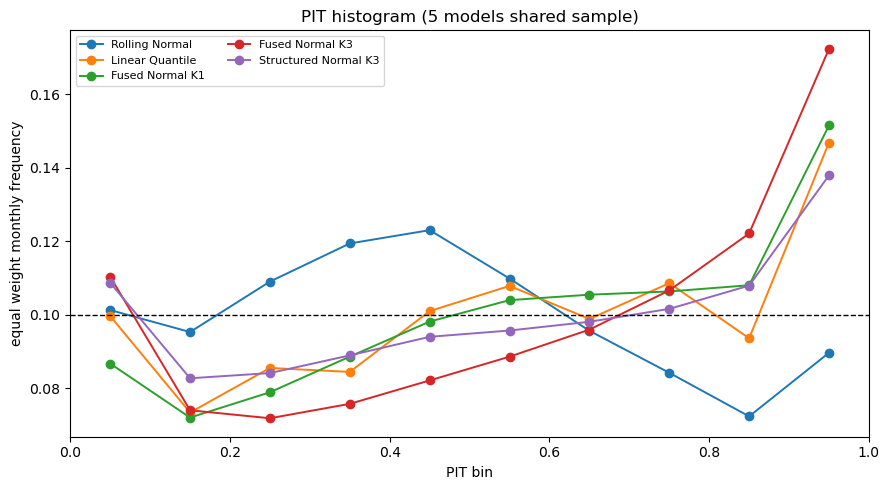

In [88]:
# ==========================================
# 10. 月份等权 PIT histogram
# ==========================================
fig, ax = plt.subplots(figsize=(9, 5))
bin_centers = (np.arange(10) + 0.5) / 10

for model_id in model_order:
    values = pit_histogram[pit_histogram["model_id"] == model_id].sort_values("pit_bin")
    ax.plot(bin_centers, values["frequency"], marker="o", linewidth=1.4, label=model_labels[model_id])

ax.axhline(0.10, color="black", linestyle="--", linewidth=1)
ax.set(xlabel="PIT bin", ylabel="equal weight monthly frequency", title="PIT histogram (5 models shared sample)", xlim=(0.0, 1.0))
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig(figure_dir / f"pit_histogram_{timestamp}.pdf", bbox_inches="tight", dpi=300)
plt.show()


In [89]:
# ==========================================
# 读取 Train+Validation 确定的 component 标签
# ==========================================
label_cols = ["adverse_component", "normal_component", "favorable_component"]
component_names = ["adverse", "normal", "favorable"]

structured_cols = key_cols + [
    "target_ret_final", "model_id", "window", *label_cols,
    "pi_vec", "mu_vec", "sigma_vec", "var_5", "es_5",
]
structured_raw = pd.read_parquet(
    model_files["structured_normal_k3"],
    columns=structured_cols,
)
structured_raw["mthcaldt"] = pd.to_datetime(structured_raw["mthcaldt"])

structured_metrics = pd.read_parquet(
    forecast_dir / f"structured_metrics_{timestamp}.parquet",
    columns=["window", "test_period", "component_mean_mu", "component_order", *label_cols],
).sort_values("window")

# 检查每个 Test 窗口只有一套标签, 意思是同一个window不会出现不同的 component 标签组合。
forecast_label_map = structured_raw[["window"] + label_cols].drop_duplicates().sort_values("window")
if forecast_label_map["window"].duplicated().any():
    raise ValueError("同一个窗口出现多套 component 标签。")

expected = structured_metrics[["window"] + label_cols].to_numpy(dtype=int)
observed = forecast_label_map[["window"] + label_cols].to_numpy(dtype=int)
if not np.array_equal(expected, observed):
    raise ValueError("forecasts 与 metrics 保存的 component 标签不一致。")

# 展示 Train+Validation 中对齐后的平均 mu
trainval_mu = decode_matrix(structured_metrics["component_mean_mu"])
trainval_order = decode_matrix(structured_metrics["component_order"]).astype(int)
trainval_mu_aligned = np.take_along_axis(trainval_mu, trainval_order, axis=1)

component_label_table = structured_metrics[["window", "test_period"] + label_cols].copy()
for k, name in enumerate(component_names):
    component_label_table[f"trainval_mean_mu_{name}"] = trainval_mu_aligned[:, k]

display(component_label_table.round(6))
component_label_table.to_parquet(result_dir / f"component_label_table_{timestamp}.parquet", index=False)

,window,test_period,adverse_component,normal_component,favorable_component,trainval_mean_mu_adverse,trainval_mean_mu_normal,trainval_mean_mu_favorable
0,0,2007-01 to 2007-12,1,2,0,-0.097681,0.010917,0.155617
1,1,2008-01 to 2008-12,0,1,2,-0.105350,0.000988,0.128545
2,2,2009-01 to 2009-12,2,0,1,-0.104454,0.004186,0.122395
3,3,2010-01 to 2010-12,1,2,0,-0.118718,-0.000299,0.103277
4,4,2011-01 to 2011-12,0,1,2,-0.128681,0.002257,0.114423
5,5,2012-01 to 2012-12,2,0,1,-0.130741,0.006383,0.123063
6,6,2013-01 to 2013-12,2,1,0,-0.110384,0.002313,0.123495
7,7,2014-01 to 2014-12,2,0,1,-0.095254,0.007794,0.134262
8,8,2015-01 to 2015-12,0,1,2,-0.110095,0.006796,0.128450
9,9,2016-01 to 2016-12,0,2,1,-0.083989,0.027348,0.132830


In [90]:
# ==========================================
# 使用已保存标签对齐 Test components
# ==========================================
pi = decode_matrix(structured_raw["pi_vec"])
mu = decode_matrix(structured_raw["mu_vec"])
sigma = decode_matrix(structured_raw["sigma_vec"])
order = structured_raw[label_cols].to_numpy(dtype=int)

pi = np.take_along_axis(pi, order, axis=1)
mu = np.take_along_axis(mu, order, axis=1)
sigma = np.take_along_axis(sigma, order, axis=1)

# 5% ES 精确分解
alpha = 0.05
q = structured_raw["var_5"].to_numpy(dtype=float)
stored_es = structured_raw["es_5"].to_numpy(dtype=float)

z = (q[:, None] - mu) / sigma
component_cdf = norm.cdf(z)
component_pdf = norm.pdf(z)

tail_weight = pi * component_cdf / alpha
es_contribution = pi * (-mu * component_cdf + sigma * component_pdf) / alpha
severity = np.divide(
    es_contribution,
    tail_weight,
    out=np.full_like(es_contribution, np.nan),
    where=tail_weight > 1e-12,
)

structured_components = structured_raw[
    key_cols + ["target_ret_final", "model_id", "window", "var_5", "es_5"]
].copy()

structured_components["effective_k"] = 1.0 / np.sum(pi ** 2, axis=1)
structured_components["max_pi"] = pi.max(axis=1)
structured_components["adverse_is_lowest_mu"] = (
    (mu[:, 0] <= mu[:, 1]) & (mu[:, 0] <= mu[:, 2])
)
structured_components["es_reconstructed_5"] = es_contribution.sum(axis=1)

for k, name in enumerate(component_names):
    structured_components[f"pi_{name}"] = pi[:, k]
    structured_components[f"mu_{name}"] = mu[:, k]
    structured_components[f"sigma_{name}"] = sigma[:, k]
    structured_components[f"tail_weight_{name}_5"] = tail_weight[:, k]
    structured_components[f"severity_{name}_5"] = severity[:, k]
    structured_components[f"es_contribution_{name}_5"] = es_contribution[:, k]

structured_components["separation_adverse_normal"] = (
    np.abs(mu[:, 0] - mu[:, 1]) /
    np.sqrt((sigma[:, 0] ** 2 + sigma[:, 1] ** 2) / 2)
)
structured_components["separation_normal_favorable"] = (
    np.abs(mu[:, 1] - mu[:, 2]) /
    np.sqrt((sigma[:, 1] ** 2 + sigma[:, 2] ** 2) / 2)
)
display(structured_components.round(6))
structured_components.to_parquet(result_dir / f"structured_components_{timestamp}.parquet", index=False)   

,permno,mthcaldt,target_ret_final,model_id,window,var_5,es_5,effective_k,max_pi,adverse_is_lowest_mu,es_reconstructed_5,pi_adverse,mu_adverse,sigma_adverse,tail_weight_adverse_5,severity_adverse_5,es_contribution_adverse_5,pi_normal,mu_normal,sigma_normal,tail_weight_normal_5,severity_normal_5,es_contribution_normal_5,pi_favorable,mu_favorable,sigma_favorable,tail_weight_favorable_5,severity_favorable_5,es_contribution_favorable_5,separation_adverse_normal,separation_normal_favorable
0,10001,2007-01-31,0.264774,structured_normal_k3,0,-0.126501,0.169206,2.378455,0.528514,False,0.169206,0.528514,0.002418,0.082986,0.635823,0.162251,0.103163,0.358145,-0.008407,0.059959,0.175081,0.149088,0.026102,0.113341,0.129864,0.185444,0.189096,0.211221,0.039941,0.149524,1.003325
1,10025,2007-01-31,-0.028094,structured_normal_k3,0,-0.269773,0.332184,2.378455,0.528514,True,0.332184,0.528514,-0.083419,0.136923,0.917017,0.332797,0.305181,0.358145,0.025016,0.116528,0.040878,0.307075,0.012553,0.113341,0.150870,0.201832,0.042105,0.343201,0.014450,0.852912,0.763699
2,10026,2007-01-31,-0.038517,structured_normal_k3,0,-0.136563,0.170743,2.378455,0.528514,True,0.170743,0.528514,-0.034472,0.074874,0.912849,0.170997,0.156094,0.358145,0.001913,0.054184,0.037957,0.153786,0.005837,0.113341,0.095101,0.114697,0.049194,0.179112,0.008811,0.556754,1.038915
3,10032,2007-01-31,-0.023810,structured_normal_k3,0,-0.464835,0.553728,2.378455,0.528514,True,0.553728,0.528514,-0.214299,0.190412,0.994956,0.553892,0.551098,0.358145,0.028570,0.144049,0.002200,0.501670,0.001104,0.113341,0.307497,0.255553,0.002844,0.536784,0.001527,1.438543,1.344660
4,10044,2007-01-31,0.021561,structured_normal_k3,0,-0.184691,0.239590,2.378455,0.528514,True,0.239590,0.528514,-0.023670,0.114855,0.850522,0.236806,0.201409,0.358145,0.013576,0.078694,0.042092,0.209954,0.008837,0.113341,0.172501,0.213775,0.107385,0.273256,0.029344,0.378325,0.986631
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
480441,93372,2024-12-31,0.093948,structured_normal_k3,17,-0.190452,0.247913,1.855908,0.686069,True,0.247913,0.254055,-0.106269,0.085338,0.822894,0.235497,0.193789,0.686069,0.039676,0.079982,0.027524,0.213807,0.005885,0.059876,0.115652,0.265997,0.149583,0.322493,0.048239,1.764678,0.386833
480442,93397,2024-12-31,-0.057236,structured_normal_k3,17,-0.103953,0.136429,1.855908,0.686069,True,0.136429,0.254055,-0.048826,0.056106,0.827779,0.133612,0.110601,0.686069,0.031148,0.050349,0.050019,0.119417,0.005973,0.059876,0.052368,0.123090,0.122203,0.162470,0.019854,1.500293,0.225656
480443,93426,2024-12-31,-0.007243,structured_normal_k3,17,-0.167370,0.216650,1.855908,0.686069,True,0.216650,0.254055,-0.091503,0.078285,0.844697,0.208966,0.176513,0.686069,0.037067,0.071308,0.028435,0.188247,0.005353,0.059876,0.110944,0.222937,0.126868,0.274178,0.034784,1.717055,0.446368
480444,93434,2024-12-31,0.147685,structured_normal_k3,17,-0.365104,0.463546,1.855908,0.686069,True,0.463546,0.254055,-0.182499,0.159668,0.642177,0.444571,0.285493,0.686069,0.020507,0.177932,0.207335,0.428253,0.088792,0.059876,0.161162,0.458772,0.150487,0.593145,0.089261,1.200890,0.404243


In [91]:
# ==========================================
# 月度和窗口层 component diagnostics
# ==========================================
monthly_agg = {
    "n_firms": ("permno", "size"),
    "effective_k": ("effective_k", "first"),
    "max_pi": ("max_pi", "first"),
    "adverse_lowest_firm_share": ("adverse_is_lowest_mu", "mean"),
    "mean_es_5": ("es_5", "mean"),
    "next_market_return_ew": ("target_ret_final", "mean"),
    "mean_separation_adverse_normal": ("separation_adverse_normal", "mean"),
    "mean_separation_normal_favorable": ("separation_normal_favorable", "mean"),
}

for name in component_names:
    monthly_agg[f"pi_{name}"] = (f"pi_{name}", "first")
    monthly_agg[f"mean_mu_{name}"] = (f"mu_{name}", "mean")
    monthly_agg[f"mean_sigma_{name}"] = (f"sigma_{name}", "mean")
    monthly_agg[f"mean_contribution_{name}"] = (f"es_contribution_{name}_5", "mean")

monthly_components = (
    structured_components.groupby(["window", "mthcaldt"], as_index=False)
    .agg(**monthly_agg)
)

monthly_components["adverse_mean_is_lowest"] = (
    (monthly_components["mean_mu_adverse"] <= monthly_components["mean_mu_normal"]) &
    (monthly_components["mean_mu_adverse"] <= monthly_components["mean_mu_favorable"])
)

window_components = monthly_components.groupby("window", as_index=False).agg(
    test_start=("mthcaldt", "min"),
    test_end=("mthcaldt", "max"),
    months=("mthcaldt", "nunique"),
    mean_effective_k=("effective_k", "mean"),
    collapse_month_share=("max_pi", lambda x: (x > 0.95).mean()),
    adverse_lowest_firm_share=("adverse_lowest_firm_share", "mean"),
    adverse_lowest_month_share=("adverse_mean_is_lowest", "mean"),
    mean_pi_adverse=("pi_adverse", "mean"),
    mean_pi_normal=("pi_normal", "mean"),
    mean_pi_favorable=("pi_favorable", "mean"),
    mean_separation_adverse_normal=("mean_separation_adverse_normal", "mean"),
    mean_separation_normal_favorable=("mean_separation_normal_favorable", "mean"),
    mean_contribution_adverse=("mean_contribution_adverse", "mean"),
    mean_total_es=("mean_es_5", "mean"),
)

pi_cols = ["pi_adverse", "pi_normal", "pi_favorable"]
pi_spread = (
    structured_components.groupby("mthcaldt")[pi_cols].max() -
    structured_components.groupby("mthcaldt")[pi_cols].min()
)

component_checks = pd.Series({
    "max_ES_reconstruction_error": np.max(
        np.abs(structured_components["es_reconstructed_5"] - stored_es)
    ),
    "max_tail_weight_sum_error": np.max(np.abs(tail_weight.sum(axis=1) - 1.0)),
    "max_within_month_pi_spread": pi_spread.to_numpy().max(),
    "mean_effective_k": monthly_components["effective_k"].mean(),
    "collapse_month_share": (monthly_components["max_pi"] > 0.95).mean(),
    "adverse_lowest_month_share": monthly_components["adverse_mean_is_lowest"].mean(),
    "adverse_lowest_firm_share": monthly_components["adverse_lowest_firm_share"].mean(),
    "adverse_ES_contribution_ratio": (
        monthly_components["mean_contribution_adverse"].mean() /
        monthly_components["mean_es_5"].mean()
    ),
})

component_check_table = component_checks.rename_axis("check").reset_index(name="value")

display(component_check_table.round(8))
display(window_components.round(6))
monthly_components.to_parquet(result_dir / f"monthly_components_{timestamp}.parquet", index=False)
window_components.to_parquet(result_dir / f"window_components_{timestamp}.parquet", index=False)
component_check_table.to_parquet(result_dir / f"component_check_table_{timestamp}.parquet", index=False) 


,check,value
0,max_ES_reconstruction_error,0.000000
1,max_tail_weight_sum_error,0.000000
2,max_within_month_pi_spread,0.000000
3,mean_effective_k,1.796170
4,collapse_month_share,0.009259
5,adverse_lowest_month_share,1.000000
6,adverse_lowest_firm_share,0.996927
7,adverse_ES_contribution_ratio,0.737834


,window,test_start,test_end,months,mean_effective_k,collapse_month_share,adverse_lowest_firm_share,adverse_lowest_month_share,mean_pi_adverse,mean_pi_normal,mean_pi_favorable,mean_separation_adverse_normal,mean_separation_normal_favorable,mean_contribution_adverse,mean_total_es
0,0,2007-01-31,2007-12-31,12,1.939435,0.000000,0.994715,1.0,0.641221,0.179254,0.179524,0.940089,0.869219,0.292825,0.331216
1,1,2008-01-31,2008-12-31,12,2.287385,0.000000,0.990249,1.0,0.429426,0.357143,0.213431,1.032118,1.099377,0.264151,0.294444
2,2,2009-01-31,2009-12-31,12,1.697424,0.000000,0.997633,1.0,0.740581,0.158831,0.100588,1.045425,1.033873,0.323571,0.327020
3,3,2010-01-31,2010-12-31,12,2.479161,0.000000,0.999369,1.0,0.309899,0.483418,0.206683,1.204738,0.940120,0.266613,0.297306
4,4,2011-01-31,2011-12-31,12,1.859414,0.000000,1.000000,1.0,0.315508,0.570473,0.114019,1.340721,0.983928,0.244904,0.287145
5,5,2012-01-31,2012-12-31,12,1.603108,0.000000,1.000000,1.0,0.045688,0.759601,0.194711,1.320070,0.937494,0.081518,0.205425
6,6,2013-01-31,2013-12-31,12,1.473474,0.000000,0.999221,1.0,0.075775,0.804705,0.119520,1.124235,1.017920,0.086862,0.204098
7,7,2014-01-31,2014-12-31,12,1.542949,0.000000,1.000000,1.0,0.363050,0.564090,0.072860,1.083070,1.143371,0.180381,0.240848
8,8,2015-01-31,2015-12-31,12,1.511068,0.000000,1.000000,1.0,0.058376,0.799198,0.142426,1.179274,1.077587,0.090258,0.196739
9,9,2016-01-31,2016-12-31,12,1.678484,0.000000,1.000000,1.0,0.254097,0.684291,0.061611,1.349318,0.846439,0.163604,0.207401


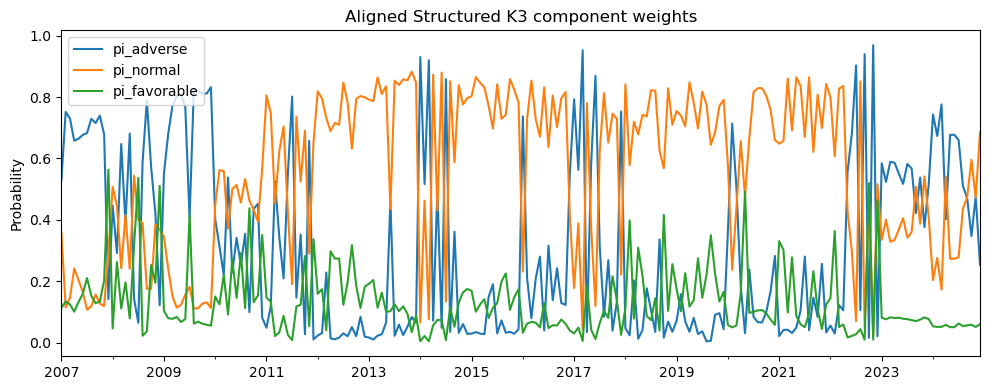

In [92]:
# ==========================================
# 检查 pi_adverse 是否预测下一月市场损失
# ==========================================
import statsmodels.api as sm

state_monthly = monthly_components[
    ["mthcaldt", "window", "pi_adverse", "pi_normal", "pi_favorable",
     "mean_es_5", "mean_contribution_adverse", "next_market_return_ew"]
].copy()
state_monthly["next_market_loss_ew"] = -state_monthly["next_market_return_ew"]
state_monthly.to_parquet(result_dir / f"state_monthly_{timestamp}.parquet", index=False)
# 这一段挪到4 pricing test里
# X = sm.add_constant(state_monthly["pi_adverse"])
# state_fit = sm.OLS(state_monthly["next_market_loss_ew"], X).fit(
#     cov_type="HAC", cov_kwds={"maxlags": 12}
# )

# ci = state_fit.conf_int().loc["pi_adverse"]
# state_validation = pd.DataFrame([{
#     "outcome": "next_market_loss_ew",
#     "coefficient_pi_adverse": state_fit.params["pi_adverse"],
#     "ci_95_low": ci.iloc[0],
#     "ci_95_high": ci.iloc[1],
#     "nw_t": state_fit.tvalues["pi_adverse"],
#     "p_value": state_fit.pvalues["pi_adverse"],
#     "months": int(state_fit.nobs),
# }])

# display(state_validation.round(6))

ax = state_monthly.set_index("mthcaldt")[pi_cols].plot(figsize=(10, 4))
ax.set(title="Aligned Structured K3 component weights", xlabel="", ylabel="Probability")
plt.tight_layout()
plt.savefig(figure_dir / f"components_weights_{timestamp}.pdf", bbox_inches="tight", dpi=300)
plt.show()